# Task 3: Customer Segmentation Using RFM Analysis

**Elevvo Pathways — Data Analytics Internship, Task 3 (Level 2)**

**Goal:** analyze customer behavior using Recency, Frequency, and Monetary (RFM) metrics,
score and group customers into segments, and suggest simple marketing ideas for each group.

**Dataset:** [Online Retail Dataset (UCI)](https://archive.ics.uci.edu/ml/datasets/online+retail)
— 541,909 e-commerce transactions from a UK-based online retailer, December 2010 to December 2011.

**Tools:** Python, pandas, seaborn, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

df = pd.read_excel('Online_Retail_Data_Set.xlsx', sheet_name='Online Retail')
print("Raw shape:", df.shape)
df.head()


Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Data Cleaning

Two checks, then one RFM-specific filter:
- **Quantity >= 1** — removes returns (recorded as negative quantities)
- **Unit Price >= 0** — removes data-entry errors
- **CustomerID must be present** — RFM is a customer-level analysis, so the ~24.6% of
  rows with no CustomerID (mostly guest/unregistered checkouts) can't be attributed to
  any customer and are excluded from this analysis specifically


In [2]:
mask_bad = (df['Quantity'] < 1) | (df['UnitPrice'] < 0)
df = df[~mask_bad].copy()
print("After Quantity/Price checks:", df.shape)

before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Dropped {before - len(df)} rows with no CustomerID -> {df.shape}")

df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("\nUnique customers:", df['CustomerID'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())


After Quantity/Price checks: (531283, 8)
Dropped 133359 rows with no CustomerID -> (397924, 8)

Unique customers: 4339
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## 2. Feature Engineering — Recency, Frequency, Monetary

For each customer, relative to a snapshot date one day after the last transaction in
the dataset:
- **Recency** — days since their most recent purchase (lower = better)
- **Frequency** — number of distinct invoices (unique purchase occasions)
- **Monetary** — total amount spent


In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm[['Recency','Frequency','Monetary']].describe()


Snapshot date: 2011-12-10 12:50:00


,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


## 3. Scoring — Quintiles (1-5)

Each metric is split into 5 equal-sized groups (quintiles). For Recency, a **lower**
number of days is better, so the labels are reversed (a customer in the most-recent
20% gets a Recency score of 5). For Frequency and Monetary, higher is better, so the
top 20% get a score of 5.


In [4]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


## 4. Segmentation

Customers are grouped into 8 named segments based on their R/F/M score combinations —
a simplified version of the standard RFM segmentation model used in retail/marketing analytics.


In [5]:
def segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if r >= 3 and f >= 4:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r >= 3 and f <= 3 and m >= 3:
        return 'Potential Loyalists'
    if r <= 2 and f >= 4:
        return 'At Risk'
    if r <= 2 and f >= 2 and m >= 4:
        return "Can't Lose Them"
    if r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    if r == 3 and f == 3 and m == 3:
        return 'Need Attention'
    return 'Hibernating'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()


Segment
Champions              962
Hibernating            915
Lost                   824
Loyal Customers        498
Potential Loyalists    414
New Customers          320
At Risk                276
Can't Lose Them        130
Name: count, dtype: int64

### Segment profile — average R/F/M, customer count, and share of revenue

In [6]:
seg_counts = rfm['Segment'].value_counts()
profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
profile['Customers'] = seg_counts
profile['% of Customers'] = (seg_counts / len(rfm) * 100).round(1)
profile['% of Revenue'] = (rfm.groupby('Segment')['Monetary'].sum() / rfm['Monetary'].sum() * 100).round(1)
profile.sort_values('Monetary', ascending=False)


,Recency,Frequency,Monetary,Customers,% of Customers,% of Revenue
Segment,,,,,,
Champions,12.9,11.1,6038.8,962,22.2,65.2
Can't Lose Them,150.8,2.3,2444.0,130,3.0,3.6
Loyal Customers,38.2,5.1,1795.7,498,11.5,10.0
At Risk,137.4,4.9,1570.6,276,6.4,4.9
Potential Loyalists,36.2,2.2,1497.4,414,9.5,7.0
Hibernating,112.9,1.7,547.3,915,21.1,5.6
New Customers,18.5,1.2,456.8,320,7.4,1.6
Lost,228.5,1.0,230.3,824,19.0,2.1


## 5. Visualizations

### Customer count by segment

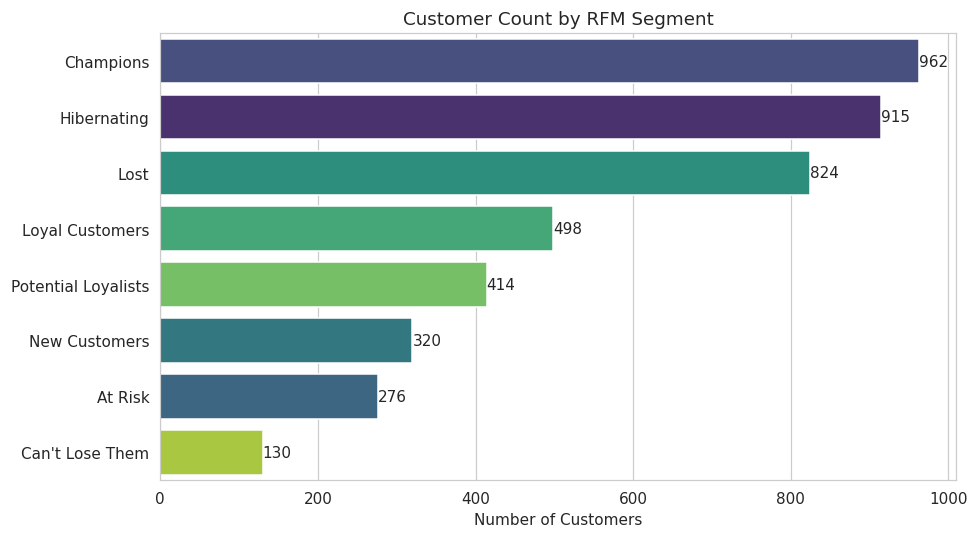

In [7]:
plt.figure(figsize=(9,5))
order = rfm['Segment'].value_counts().index
ax = sns.countplot(data=rfm, y='Segment', order=order, hue='Segment', palette='viridis', legend=False)
plt.title('Customer Count by RFM Segment')
plt.xlabel('Number of Customers'); plt.ylabel('')
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout(); plt.show()


### Total revenue by segment

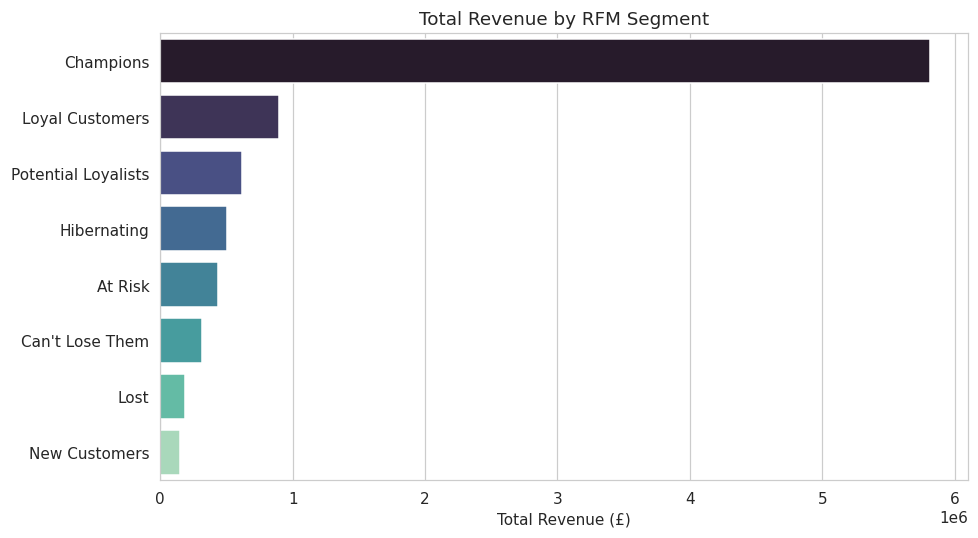

In [8]:
plt.figure(figsize=(9,5))
rev_by_seg = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
ax = sns.barplot(x=rev_by_seg.values, y=rev_by_seg.index, hue=rev_by_seg.index, palette='mako', legend=False)
plt.title('Total Revenue by RFM Segment')
plt.xlabel('Total Revenue (£)'); plt.ylabel('')
plt.tight_layout(); plt.show()


### Bonus: RFM heatmap — customer count (Recency x Frequency)

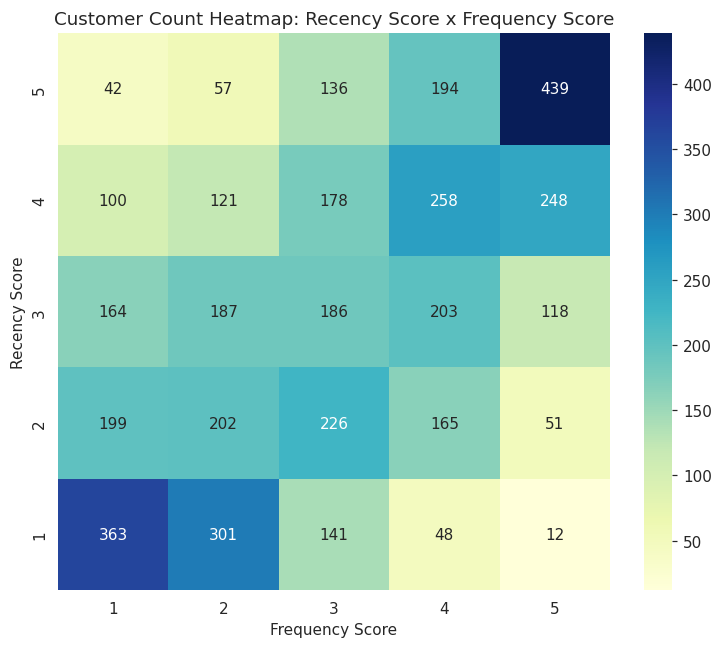

In [9]:
plt.figure(figsize=(7,6))
pivot = rfm.pivot_table(index='R_Score', columns='F_Score', values='CustomerID', aggfunc='count', fill_value=0)
pivot = pivot.sort_index(ascending=False)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Customer Count Heatmap: Recency Score x Frequency Score')
plt.xlabel('Frequency Score'); plt.ylabel('Recency Score')
plt.tight_layout(); plt.show()


### Bonus: RFM heatmap — average spend (Recency x Frequency)

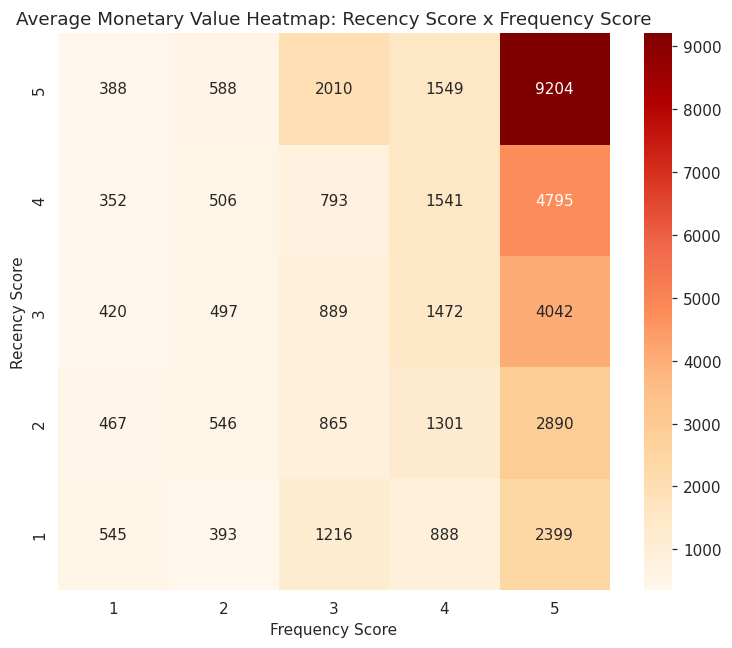

In [10]:
plt.figure(figsize=(7,6))
pivot_m = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean', fill_value=0)
pivot_m = pivot_m.sort_index(ascending=False)
sns.heatmap(pivot_m, annot=True, fmt='.0f', cmap='OrRd')
plt.title('Average Monetary Value Heatmap: Recency Score x Frequency Score')
plt.xlabel('Frequency Score'); plt.ylabel('Recency Score')
plt.tight_layout(); plt.show()


### Recency vs. Frequency, colored by segment

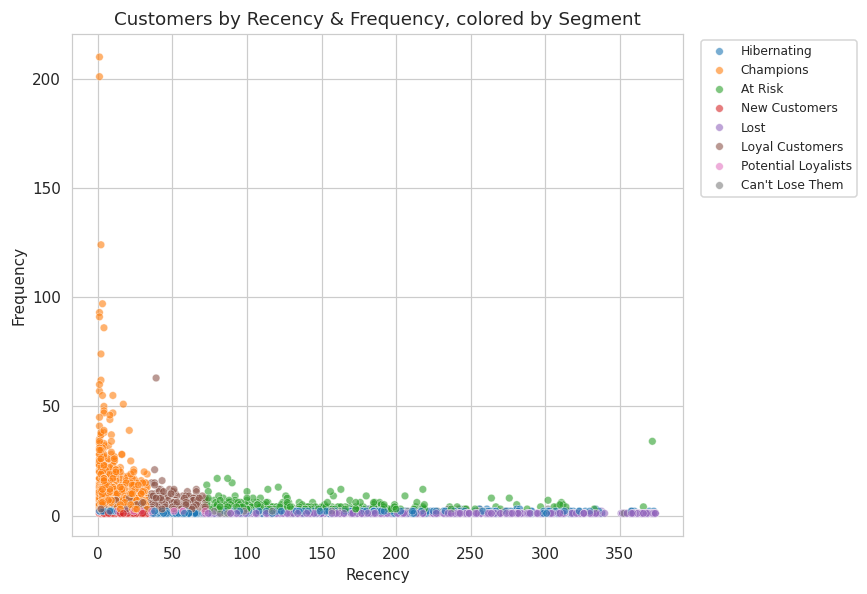

In [11]:
plt.figure(figsize=(8,5.5))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', palette='tab10', alpha=0.6, s=25)
plt.title('Customers by Recency & Frequency, colored by Segment')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


### Share of total revenue by segment

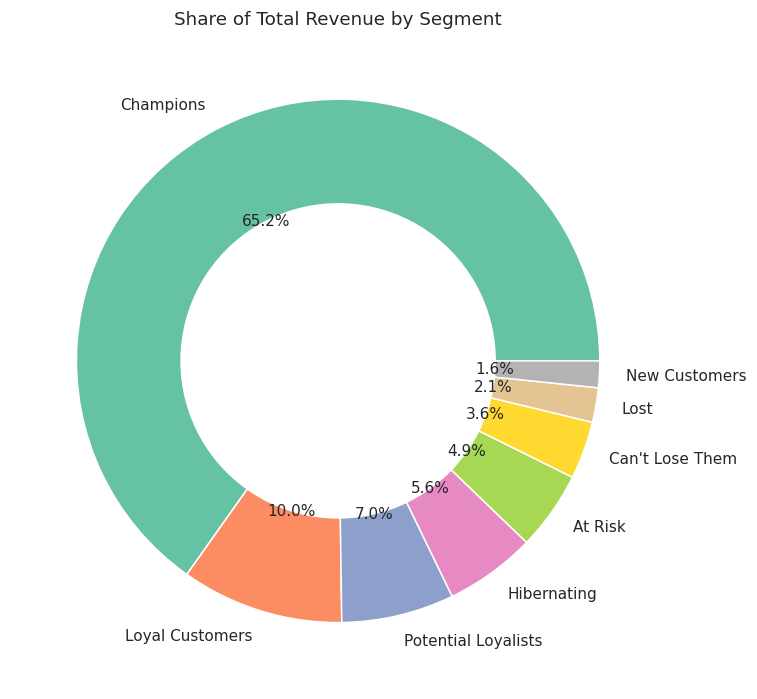

In [12]:
plt.figure(figsize=(7,7))
rev_share = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(rev_share))
plt.pie(rev_share, labels=rev_share.index, autopct='%1.1f%%', colors=colors, wedgeprops={'width':0.4})
plt.title('Share of Total Revenue by Segment')
plt.tight_layout(); plt.show()


## 6. Marketing Recommendations by Segment

| Segment | Who they are | Suggested action |
|---|---|---|
| **Champions** (22.2% of customers, **65.2% of revenue**) | Bought recently, often, and spend the most | Reward loyalty: VIP perks, early access to new products, referral incentives. Don't discount unnecessarily — they're already buying. |
| **Loyal Customers** (11.5%, 10.0% of revenue) | Buy fairly often and recently | Upsell/cross-sell higher-value items; invite into a loyalty points program. |
| **Potential Loyalists** (9.5%, 7.0% of revenue) | Recent buyers, moderate spend, not yet frequent | Encourage a second/third purchase with limited-time offers and personalized product recommendations. |
| **New Customers** (7.4%, 1.6% of revenue) | Just made their first purchase | Onboarding email series, a welcome discount on their next order, product education. |
| **At Risk** (6.4%, 4.9% of revenue) | Used to buy often, haven't been back recently | Personalized win-back campaign — "we miss you" email with a time-limited discount. |
| **Can't Lose Them** (3.0%, 3.6% of revenue) | High past spenders who have gone quiet | Highest-priority re-engagement — personal outreach or an exclusive high-value offer before they're lost for good. |
| **Hibernating** (21.1%, 5.6% of revenue) | Low frequency, moderate lapse, low spend | Low-cost broad reactivation campaigns; a short survey can help understand why they disengaged. |
| **Lost** (19.0%, only 2.1% of revenue) | Haven't bought in a long time, low value historically | Minimal marketing spend — one low-cost reactivation email; not worth heavy investment given the low expected return. |

**Key takeaway:** Champions are only 22% of customers but drive nearly two-thirds of
revenue — protecting and rewarding this group matters more than acquiring new customers.
Meanwhile, Lost customers are the single largest segment by count (19%) but contribute
almost nothing to revenue, so marketing spend is better redirected toward the At Risk
and Can't Lose Them segments, where meaningful revenue is still recoverable.
